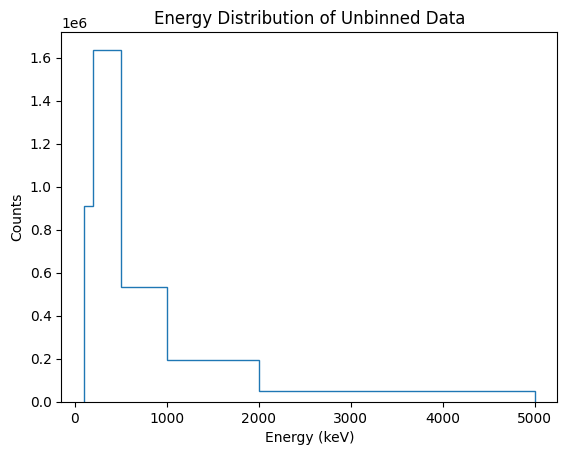

In [22]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

# code is from StackOverflow https://stackoverflow.com/questions/46733052/read-hdf5-file-into-numpy-array
hf = h5py.File("unbinned_data.hdf5", "r")
dict_to_arr = hf.get('Energies')             # found key from cosipy read the docs under the function read_tra
energy_values = np.array(dict_to_arr)


#plt.hist returns a np.array of ([values], [edges])
Energy_count, Energy_bins, patches= plt.hist(energy_values, bins=[100.,  200.,  500., 1000., 2000., 5000.], histtype='step')

# axis is count vs energy
plt.xlabel("Energy (keV)")
plt.ylabel("Counts")
plt.title("Energy Distribution of Unbinned Data")
plt.show()

# try y-axis / x-axis to get the rate for light curve
# or try y-axis / x1-x2 to get the range of bins for light curve

In [23]:
bins_widths_center = (Energy_bins[1:] + Energy_bins[0:-1])

[ 100.  300.  500. 1000. 3000.]


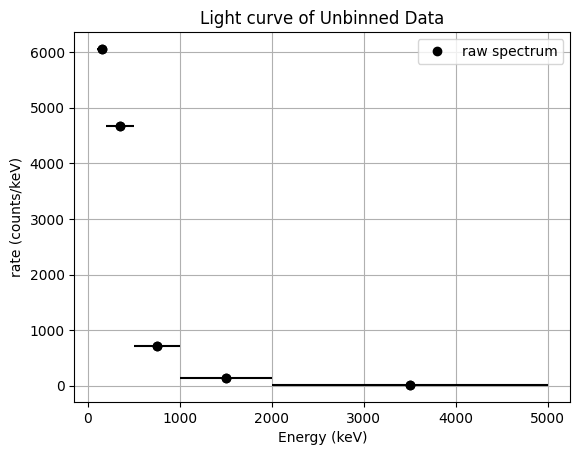

In [ ]:
import matplotlib.pyplot as plt

hf = h5py.File("unbinned_data.hdf5", "r")

# spectra graph is rate (count/keV^-1) vs energy (kev)
# x axis are the energy means???? idk man

# y axis is the rate (y/x from the histogram)
bins_widths_center = (Energy_bins[1:] + Energy_bins[0:-1]) / 2
rate = Energy_count / bins_widths_center  # rate is counts per bin width

#formating it all together

plt.plot(bins_widths_center, rate, marker='o', color = 'black', linestyle='None', label = 'raw spectrum')

# why????? is it / 2, maybe becasue im plotting them in the center
x_errors = (Energy_bins[1:] - Energy_bins[0:-1]) / 2  # calculate the bin widths for error bars

print((Energy_bins[1:] - Energy_bins[0:-1]))

plt.errorbar(bins_widths_center, rate, xerr=x_errors, fmt='o', color='black')


plt.xlabel("Energy (keV)")
plt.ylabel("rate (counts/keV)")
plt.title("Light curve of Unbinned Data")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
time_arr = hf.get('TimeTags')  # found key from cosipy read the docs under the function read_tra
time_values = np.array(time_arr)    


# light curve is rate vs time
relative_time = time_values - time_values[0]  # make the first time tag zero
count_times, time_bins = np.histogram(time_values, bins=10)  # this is the histogram of the time tags

print(time_values)
print(time_bins)  # this is the bin edges

bin_width = time_bins - time_bins[0]  # calculate the bin width
print(bin_width)


# plt.hist(time_values, bins=1000, histtype='step', lw = 2)
# plt.xlabel("Time (s)")
# plt.ylabel("counts")
# plt.title("Histogram of Time Tags")
# plt.show() 


[1.8354780e+09 1.8354780e+09 1.8354780e+09 ... 1.8354852e+09 1.8354852e+09
 1.8354852e+09]
[1.83547800e+09 1.83547872e+09 1.83547944e+09 1.83548016e+09
 1.83548088e+09 1.83548160e+09 1.83548232e+09 1.83548304e+09
 1.83548376e+09 1.83548448e+09 1.83548520e+09]
[   0.          719.99949455 1439.99898911 2159.99848342 2879.99797797
 3599.99747252 4319.99696708 5039.99646163 5759.99595594 6479.9954505
 7199.99494505]


In [ ]:
#rate = count / bins_widths


#x-axis is time_bins
time_bins = time_bins - time_bins[0]  # make the first time tag zero
time_bin_center = (time_bins[1:] + time_bins[0:-1]) / 2

# y-axis is rate (y/x from the histogram)
time_bin_widths = time_bins[1:] - time_bins[0:-1]
rate_times = count_times / time_bin_widths  # rate is counts per bin width

print(time_bin_widths.shape)

plt.semilogy(time_bin_center, rate_times, linestyle='-')
plt.xlabel("Time (s)")
plt.ylabel("Rate (counts/s)")
plt.title("Light Curve of Unbinned Data")
plt.grid(True)
plt.show()


# this graph is wrong becasue of the x axis??? im not sure of how to format it to bins of 60 seconds in time graph

# not sure using the realative time method is the correct way of doing it

# however the graph is following the trend of the provided graphs in the cosipy readme???

NameError: name 'time_bins' is not defined

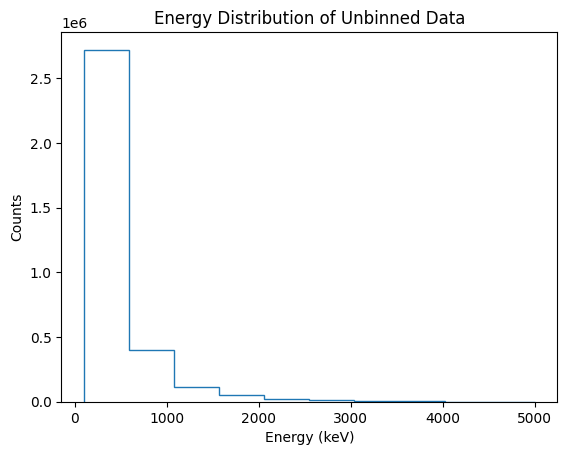

[244.99655 244.99655 244.99655 244.99655 244.99655 244.99655 244.99655
 244.99655 244.99655 244.99655]


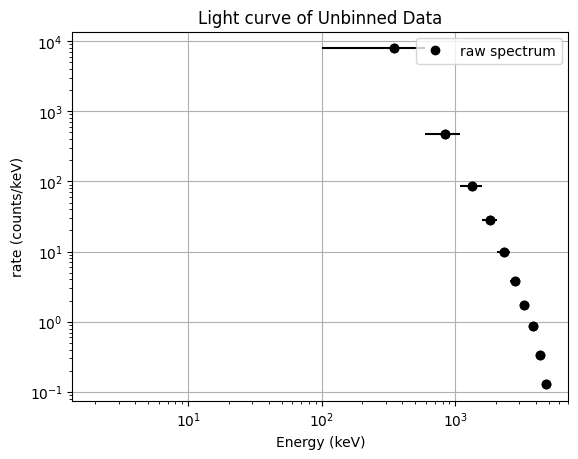

In [10]:
## binning reso

import h5py
import matplotlib.pyplot as plt
import numpy as np

# code is from StackOverflow https://stackoverflow.com/questions/46733052/read-hdf5-file-into-numpy-array
hf = h5py.File("unbinned_data.hdf5", "r")
dict_to_arr = hf.get('Energies')             # found key from cosipy read the docs under the function read_tra
energy_values = np.array(dict_to_arr)


#plt.hist returns a np.array of ([values], [edges])
Energy_count, Energy_bins, patches= plt.hist(energy_values, bins=10, histtype='step')

# axis is count vs energy
plt.xlabel("Energy (keV)")
plt.ylabel("Counts")
plt.title("Energy Distribution of Unbinned Data")
plt.show()

# try y-axis / x-axis to get the range of bins for light curve
# or try y-axis / x1-x2 to get the range of bins for light curve


bins_widths_center = (Energy_bins[1:] + Energy_bins[0:-1]) / 2


import matplotlib.pyplot as plt

hf = h5py.File("unbinned_data.hdf5", "r")

# spectra graph is rate (count/keV^-1) vs energy (kev)
# x axis are the energy means???? idk man

# y axis is the rate (y/x from the histogram)
bins_widths_center = (Energy_bins[1:] + Energy_bins[0:-1]) / 2
rate = Energy_count / bins_widths_center  # rate is counts per bin width

#formating it all together
plt.loglog(bins_widths_center, rate, marker='o', color = 'black', linestyle='None', label = 'raw spectrum')

# why????? is it / 2
y_errors = (Energy_bins[1:] - Energy_bins[0:-1]) / 2  # calculate the bin widths for error bars

print(y_errors)

plt.errorbar(bins_widths_center, rate, xerr=y_errors, fmt='o', color='black')


plt.xlabel("Energy (keV)")
plt.ylabel("rate (counts/keV)")
plt.title("Light curve of Unbinned Data")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from cosipy import BinnedData
%matplotlib inline 

analysis = BinnedData("inputs.yaml")
analysis.read_tra(output_name="unbinned_data")
analysis.get_binned_data()